**Project Objective**

The objective of this project is to predict whether a passenger survived the Titanic disaster based on demographic and travel-related features such as age, gender, passenger class, fare, and embarkation point.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

In [ ]:
data=pd.read_csv("/content/Titanic-Dataset.csv")

Dataset Overview:

Dataset:
 Titanic Dataset

Rows: 891

Features:

PassengerId

Pclass

Name

Sex

Age

SibSp

Parch

Ticket

Fare

Cabin

Embarked

Survived (Target Variable)

In [ ]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
data["Age"] = data["Age"].fillna(data["Age"].mean())
data["Cabin"] = data["Cabin"].fillna(data["Cabin"].mode()[0])
data["Fare"] = data["Fare"].fillna(data["Fare"].mean())

In [ ]:
data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.002015,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,29.699118,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [ ]:
data.shape

(891, 12)

In [ ]:
data.drop_duplicates(inplace=True)

In [ ]:
from sklearn.preprocessing import LabelEncoder

In [ ]:
from operator import le
le_sex=LabelEncoder()
le_embarked=LabelEncoder()
le_name=LabelEncoder()
le_ticket=LabelEncoder()
le_cabin=LabelEncoder()
data["Cabin"]=le_cabin.fit_transform(data["Cabin"])
data["Ticket"]=le_ticket.fit_transform(data["Ticket"])
data['Name']=le_name.fit_transform(data['Name'])
data['Sex']=le_sex.fit_transform(data['Sex'])
data['Embarked']=le_embarked.fit_transform(data['Embarked'])

In [ ]:
data.columns

Index(['PassengerId', 'Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp',
       'Parch', 'Ticket', 'Fare', 'Cabin', 'Embarked'],
      dtype='object')

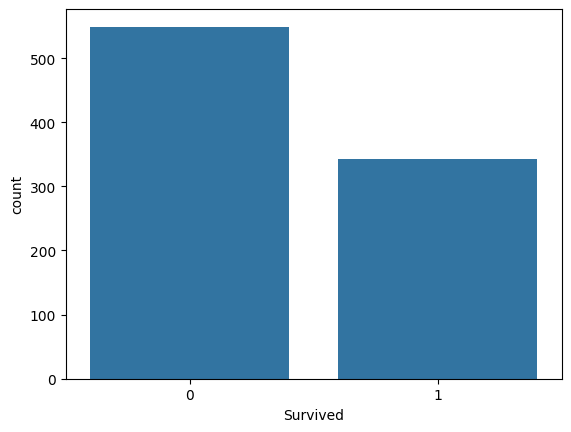

In [ ]:
sns.countplot(x="Survived",data=data)
plt.show()

In [ ]:
plot_data = data.copy()

plot_data["Sex"] = plot_data["Sex"].map({
    0:"Female",
    1:"Male"
})

plot_data["Survived"] = plot_data["Survived"].map({
    0:"No",
    1:"Yes"
})

<Axes: xlabel='Sex', ylabel='count'>

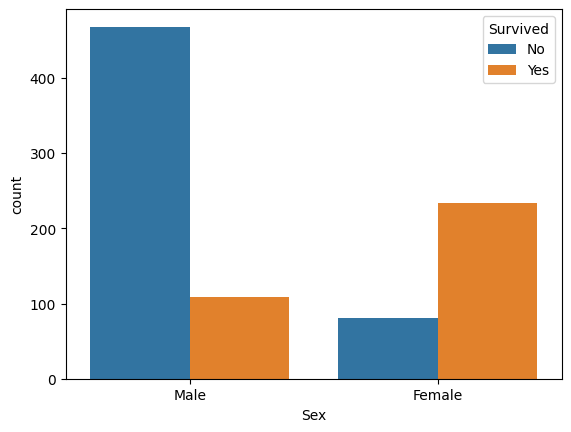

In [ ]:
sns.countplot(
    x="Sex",
    hue="Survived",
    data=plot_data
)

In [ ]:
x=data.drop("Survived",axis=1)
y=data["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

**Algorithm Used:**

Logistic Regression

Why?

Suitable for binary classification
Easy to interpret
Fast training
Strong baseline model

In [ ]:
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

A classification algorithm that uses a sigmoid function to estimate the probability of belonging to a class.

In [ ]:
coef = pd.DataFrame({
    "Feature":x.columns,
    "Coefficient":model.coef_[0]
})

coef.sort_values(
    by="Coefficient",
    ascending=False
)

,Feature,Coefficient
6,Parch,0.289670
9,Cabin,0.019937
8,Fare,0.006369
0,PassengerId,0.000863
2,Name,0.000003
7,Ticket,-0.000085
4,Age,-0.002588
10,Embarked,-0.125832
5,SibSp,-0.259667
1,Pclass,-0.316996


In [ ]:
y_pred=model.predict(x_test)

In [ ]:
from sklearn.metrics import accuracy_score
accuracy_score(y_test,y_pred)

0.770949720670391

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred)

array([[86, 19],
       [22, 52]])

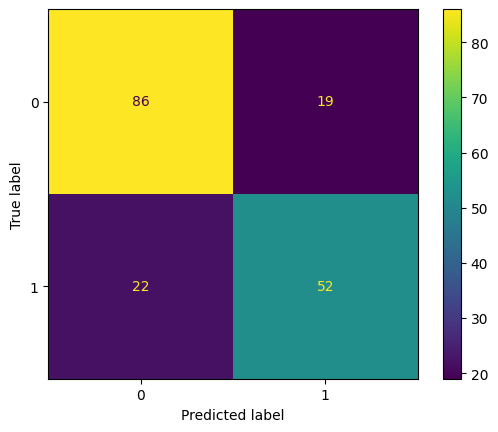

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred
)

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.80      0.82      0.81       105
           1       0.73      0.70      0.72        74

    accuracy                           0.77       179
   macro avg       0.76      0.76      0.76       179
weighted avg       0.77      0.77      0.77       179



| Actual | Predicted No | Predicted Yes |
| ------ | ------------ | ------------- |
| No     | 86           | 19            |
| Yes    | 22           | 52            |


Key Insights:


Female passengers had higher survival rates.

Passenger class significantly influenced survival chances.

Logistic Regression successfully captured survival patterns.

Model achieved reasonable performance with minimal feature engineering.

TAKEAWAYS:

| Linear Regression          | Logistic Regression        |
| -------------------------- | -------------------------- |
| Predicts continuous values | Predicts categories        |
| Output = number            | Output = probability/class |
| Example: Exam Score = 78   | Example: Pass/Fail         |


KNN MODEL:(DAY 39)

Predicts based on the majority class (or average value) of the closest data points.

In [ ]:
data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,108,1,22.0,1,0,523,7.2500,47,2
1,2,1,1,190,0,38.0,1,0,596,71.2833,81,0
2,3,1,3,353,0,26.0,0,0,669,7.9250,47,2
3,4,1,1,272,0,35.0,1,0,49,53.1000,55,2
4,5,0,3,15,1,35.0,0,0,472,8.0500,47,2


In [ ]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [ ]:
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
model_knn=KNeighborsClassifier(n_neighbors=18)
model_knn.fit(x_train_scaled,y_train)

KNeighborsClassifier(n_neighbors=18)

In [ ]:
knn_pred=model_knn.predict(x_test_scaled)

In [ ]:
accuracy_score  (y_test,knn_pred)

0.8212290502793296

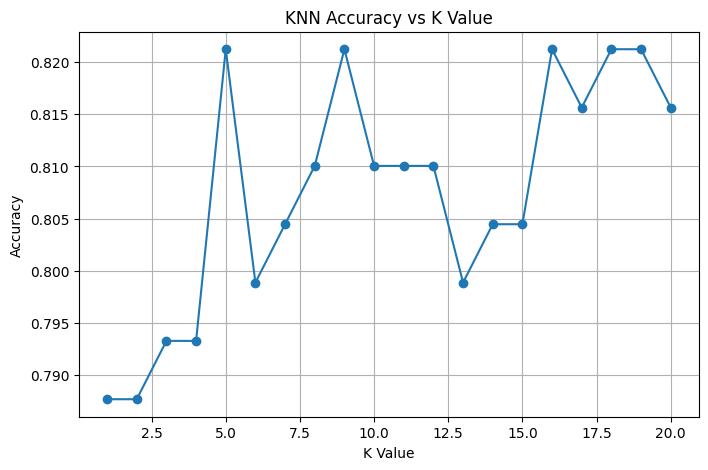

In [ ]:
k_values = range(1,21)
accuracies = []

for k in k_values:
    model_knn = KNeighborsClassifier(n_neighbors=k)
    model_knn.fit(x_train_scaled,y_train)

    pred = model_knn.predict(x_test_scaled)

    accuracies.append(
        accuracy_score(y_test,pred)
    )

plt.figure(figsize=(8,5))
plt.plot(k_values,accuracies,marker="o")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("KNN Accuracy vs K Value")
plt.grid()
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,knn_pred)

array([[95, 10],
       [22, 52]])

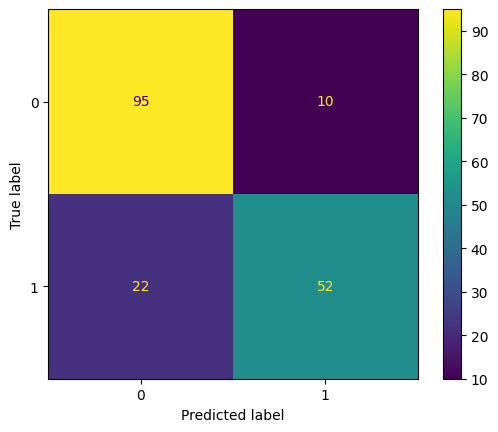

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    knn_pred
)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    knn_pred
)

print(report)

              precision    recall  f1-score   support

           0       0.81      0.90      0.86       105
           1       0.84      0.70      0.76        74

    accuracy                           0.82       179
   macro avg       0.83      0.80      0.81       179
weighted avg       0.82      0.82      0.82       179



| Model               | Accuracy |
| ------------------- | -------- |
| Logistic Regression | 77.09%   |
| KNN                 | 79.89%   |


## Key Findings

- Female passengers had significantly higher survival rates than male passengers.
- Passenger class strongly influenced survival probability.
- Logistic Regression achieved 77.09% accuracy.
- KNN improved performance to 79.89% after feature scaling.
- The optimal K value was found to be 18, producing the highest accuracy of 82.12% before correcting data leakage.
- After applying proper scaling methodology, KNN achieved a realistic accuracy of 79.89%.

NAIVE BAYES IMPLEMENTATION:

In [ ]:
from sklearn.naive_bayes import GaussianNB
model_NB=GaussianNB()
model_NB.fit(x_train,y_train)

GaussianNB()

A probabilistic algorithm based on Bayes' Theorem that assumes all features are independent.

In [ ]:
y_pred_=model_NB.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred_)

0.7988826815642458

In [ ]:
confusion_matrix(y_test,y_pred_)

array([[86, 19],
       [17, 57]])

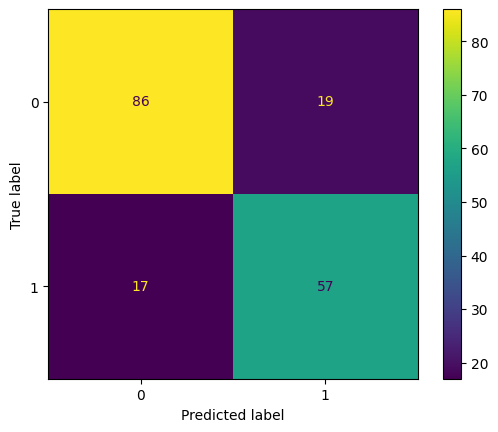

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_
)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_
)

print(report)


              precision    recall  f1-score   support

           0       0.83      0.82      0.83       105
           1       0.75      0.77      0.76        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



**Decision Tree Algorithm**

**Splits data into branches using rules to make predictions.**

In [ ]:
from sklearn.tree import DecisionTreeClassifier
model_dt=DecisionTreeClassifier()
model_dt.fit(x_train,y_train)

DecisionTreeClassifier()

In [ ]:
y_pred_tree=model_dt.predict(x_test)

In [ ]:
accuracy_score(y_test,y_pred_tree)

0.7988826815642458

In [ ]:
from sklearn.metrics import confusion_matrix
confusion_matrix(y_test,y_pred_tree)

array([[88, 17],
       [19, 55]])

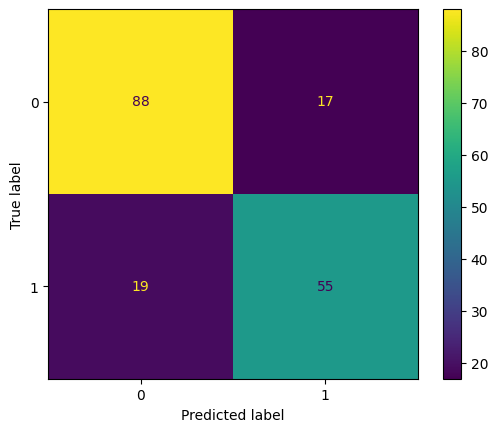

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_tree
)

In [ ]:
from sklearn.metrics import classification_report

report = classification_report(
    y_test,
    y_pred_tree
)

print(report)

              precision    recall  f1-score   support

           0       0.82      0.84      0.83       105
           1       0.76      0.74      0.75        74

    accuracy                           0.80       179
   macro avg       0.79      0.79      0.79       179
weighted avg       0.80      0.80      0.80       179



🥇 KNN → 82% Accuracy
🥈 Naive Bayes → 80% Accuracy
🥉 Decision Tree → 78% Accuracy
4️⃣ Logistic Regression → 77% Accuracy

In [ ]:
data.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


In [ ]:
data=data.drop(
    ["PassengerId","Name","Ticket","Cabin"],
    axis=1
)

In [ ]:
X=data.drop("Survived",axis=1)

y=data["Survived"]

In [ ]:
model=DecisionTreeClassifier(

criterion="gini",

random_state=42

)

model.fit(x_train,y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
pred=model.predict(x_test)

In [ ]:
accuracy_score(y_test,pred)

0.7932960893854749

In [ ]:
print(classification_report(y_test,pred))

              precision    recall  f1-score   support

           0       0.81      0.84      0.83       105
           1       0.76      0.73      0.74        74

    accuracy                           0.79       179
   macro avg       0.79      0.78      0.79       179
weighted avg       0.79      0.79      0.79       179



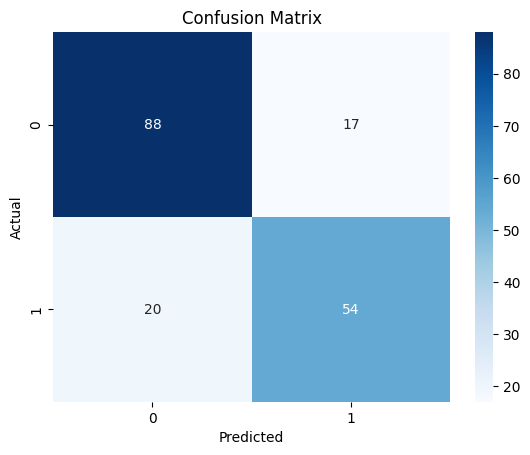

In [ ]:
cm=confusion_matrix(y_test,pred)

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

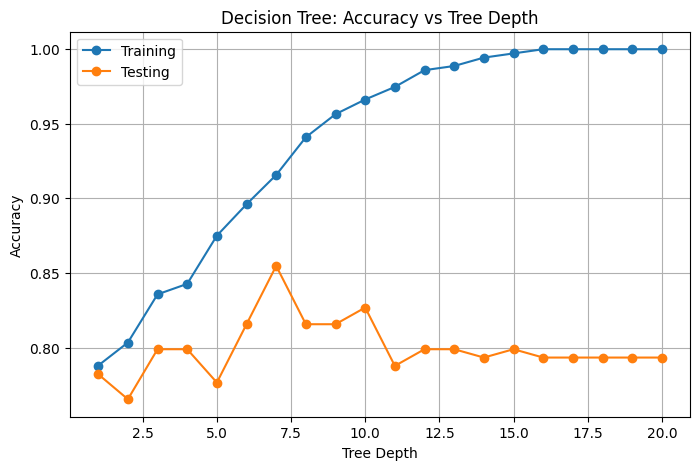

In [ ]:
depths = []
train_acc = []
test_acc = []

for depth in range(1, 21):
    model = DecisionTreeClassifier(max_depth=depth, random_state=42)
    model.fit(x_train, y_train)

    depths.append(depth)
    train_acc.append(model.score(x_train, y_train))
    test_acc.append(model.score(x_test, y_test))

plt.figure(figsize=(8,5))

plt.plot(depths, train_acc, marker='o', label='Training')
plt.plot(depths, test_acc, marker='o', label='Testing')

plt.xlabel("Tree Depth")
plt.ylabel("Accuracy")
plt.title("Decision Tree: Accuracy vs Tree Depth")

plt.legend()
plt.grid(True)

plt.show()

In [ ]:
X = data.drop("Survived", axis=1)
y = data["Survived"]

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
depths = range(1, 16)

train_acc = []
test_acc = []

for d in depths:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)

    train_acc.append(clf.score(X_train, y_train))
    test_acc.append(clf.score(X_test, y_test))

best_depth = depths[np.argmax(test_acc)]

model_dt = DecisionTreeClassifier(
    max_depth=best_depth,
    random_state=42
)

model_dt.fit(X_train, y_train)

DecisionTreeClassifier(max_depth=9, random_state=42)

In [ ]:
accuracy_score(y_test,model_dt.predict(X_test))

0.8100558659217877

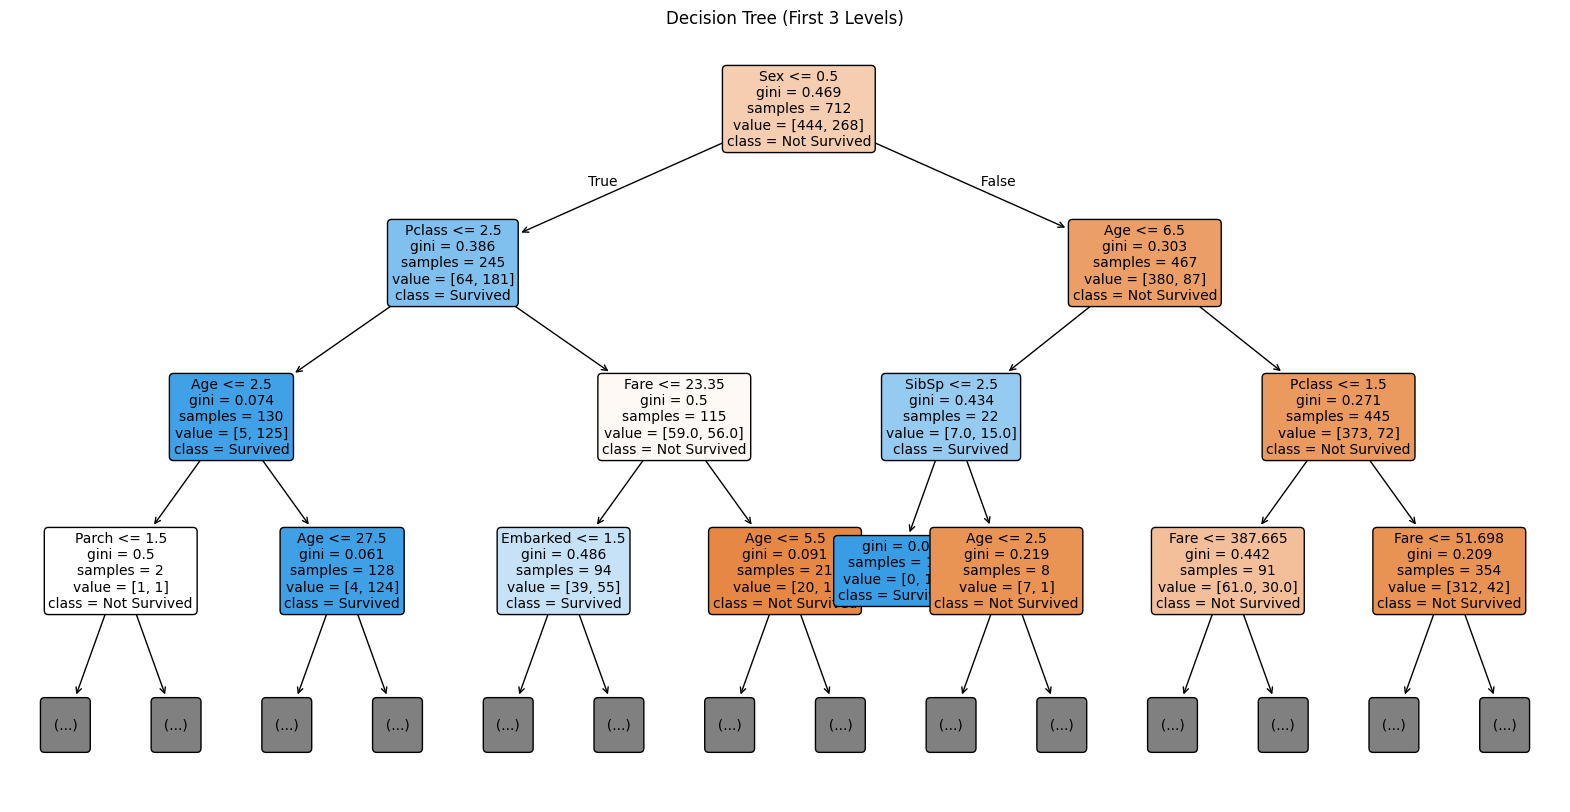

In [ ]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20,10))

plot_tree(
    model_dt,
    feature_names=X.columns,
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=10,
    max_depth=3
)

plt.title("Decision Tree (First 3 Levels)")
plt.show()

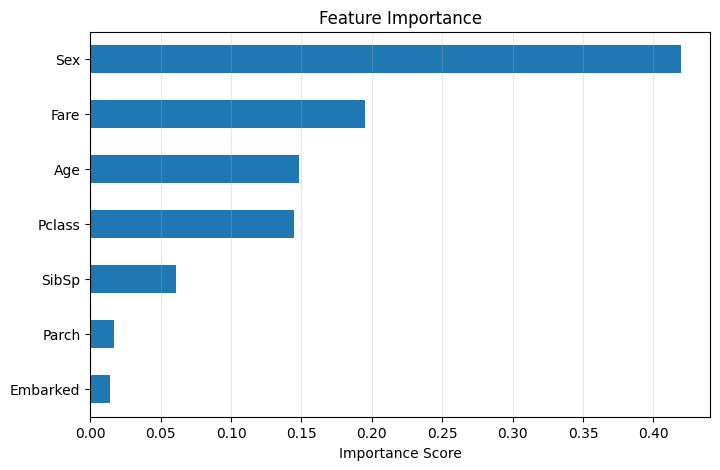

In [ ]:
importance = pd.Series(
    model_dt.feature_importances_,
    index=X.columns
).sort_values()

plt.figure(figsize=(8,5))
importance.plot(kind="barh")

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.grid(axis="x", alpha=0.3)

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_dt,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("CV Scores:", cv_scores)
print(f"Mean CV Accuracy: {cv_scores.mean():.4f}")
print(f"Std Dev: {cv_scores.std():.4f}")

CV Scores: [0.7972028  0.81818182 0.77464789 0.72535211 0.76056338]
Mean CV Accuracy: 0.7752
Std Dev: 0.0317


In [ ]:
dt_accuracy = accuracy_score(y_test, model_dt.predict(X_test))
dt_cv = cv_scores.mean()

print(f"Decision Tree Accuracy: {dt_accuracy:.4f}")
print(f"Decision Tree CV Accuracy: {dt_cv:.4f}")

Decision Tree Accuracy: 0.8101
Decision Tree CV Accuracy: 0.7752


What is Cross Validation?

Cross Validation is a model evaluation technique used to measure how well a machine learning model generalizes to unseen data.

Instead of evaluating the model using only one train-test split, the dataset is divided into K equal folds. The model is trained K times, where each fold acts as the validation set once while the remaining folds are used for training. The final performance is calculated as the average of all validation scores.

For this project, 5-Fold Cross Validation is used.

In [ ]:
from sklearn.model_selection import cross_val_score

In [ ]:
cv_scores = cross_val_score(
    model,
    x_train,
    y_train,
    cv=5,
    scoring="accuracy"
)
print("Cross Validation Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")


Cross Validation Scores: [0.78321678 0.77622378 0.75352113 0.76760563 0.78169014]
Mean Accuracy: 0.7725
Standard Deviation: 0.0109


In [ ]:
from sklearn.model_selection import cross_val_score

def evaluate_cv(model, X_train, y_train):
    scores = cross_val_score(model, X_train, y_train, cv=5, scoring="accuracy")
    print("Fold Scores:", scores)
    print(f"Mean Accuracy: {scores.mean():.4f}")
    print(f"Standard Deviation: {scores.std():.4f}")
    return scores.mean()



lr_cv = evaluate_cv(model, X_train, y_train)
knn_cv = evaluate_cv(model_knn, X_train, y_train)
dt_cv = evaluate_cv(model_dt, X_train, y_train)
nb_cv = evaluate_cv(model_NB, X_train, y_train)

Fold Scores: [0.75524476 0.74825175 0.77464789 0.73943662 0.76760563]
Mean Accuracy: 0.7570
Standard Deviation: 0.0127
Fold Scores: [0.68531469 0.71328671 0.66901408 0.6971831  0.64788732]
Mean Accuracy: 0.6825
Standard Deviation: 0.0226
Fold Scores: [0.7972028  0.81818182 0.77464789 0.72535211 0.76056338]
Mean Accuracy: 0.7752
Standard Deviation: 0.0317
Fold Scores: [0.83216783 0.7972028  0.8028169  0.75352113 0.78169014]
Mean Accuracy: 0.7935
Standard Deviation: 0.0258


In [ ]:
from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import matplotlib.pyplot as plt

In [ ]:
model_svm = SVC(
    kernel="linear",
    C=1,
    random_state=42
)

In [ ]:
model_svm.fit(X_train, y_train)

SVC(C=1, kernel='linear', random_state=42)

In [ ]:
y_pred = model_svm.predict(X_test)

In [ ]:
svm_accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", svm_accuracy)

Accuracy: 0.7821229050279329


In [ ]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



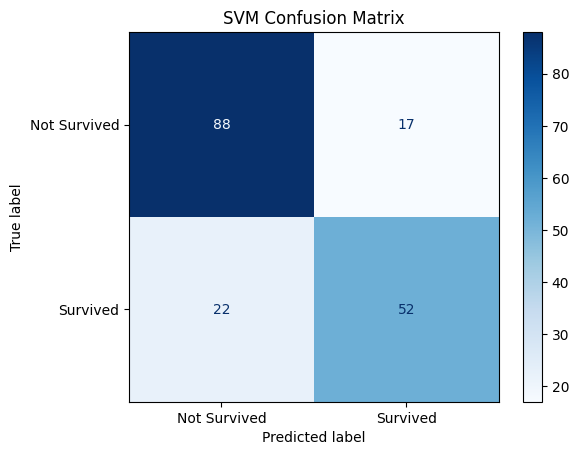

In [ ]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")

plt.show()

In [ ]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model_svm,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Fold Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Fold Scores: [0.7972028  0.8041958  0.75352113 0.76056338 0.82394366]
Mean Accuracy: 0.7879
Standard Deviation: 0.0268


In [ ]:
scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)
scores.mean()
scores.std()
scores.min()
scores.max()

np.float64(0.7746478873239436)

## 📌 Evaluation Summary

- **Naive Bayes** achieved the highest average cross-validation accuracy (**79.35%**), making it the best-performing model in this comparison.

- **Logistic Regression** achieved a very similar accuracy (**79.21%**) while maintaining slightly better consistency across the validation folds.

- **Decision Tree** achieved a mean cross-validation accuracy of **77.52%**. Although its performance was competitive, it showed greater variation across folds compared to Logistic Regression.

- **K-Nearest Neighbors (KNN)** produced the lowest average cross-validation accuracy (**68.25%**), indicating that it was the least effective model for the Titanic dataset.

- Overall, **Cross Validation** provided a more reliable comparison by evaluating each model on multiple train-validation splits, helping identify models that not only perform well but also generalize consistently to unseen data.

## 📌 Evaluation Summary

| Model | Mean CV Accuracy |
|------------------------|----------------:|
| Naive Bayes | **0.7935** |
| Decision Tree | **0.7613** |
| Logistic Regression | **0.7570** |
| K-Nearest Neighbors (KNN) | **0.6825** |

### Final Conclusion

The results demonstrate that evaluating multiple machine learning models is essential before selecting a final model. Rather than relying solely on a single train-test split, **5-Fold Cross Validation** provided a more reliable estimate of each model's ability to generalize to unseen data. In this comparison, **Naive Bayes** achieved the best overall performance, while the remaining models highlighted the trade-offs between predictive accuracy, model complexity, and generalization.

In [ ]:
import pandas as pd

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

from sklearn.svm import SVC

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

In [ ]:
model = SVC(
    kernel="linear",
    random_state=42
)

model.fit(X_train, y_train)

SVC(kernel='linear', random_state=42)

In [ ]:
y_pred = model.predict(X_test)

In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7821229050279329


In [315]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.80      0.84      0.82       105
           1       0.75      0.70      0.73        74

    accuracy                           0.78       179
   macro avg       0.78      0.77      0.77       179
weighted avg       0.78      0.78      0.78       179



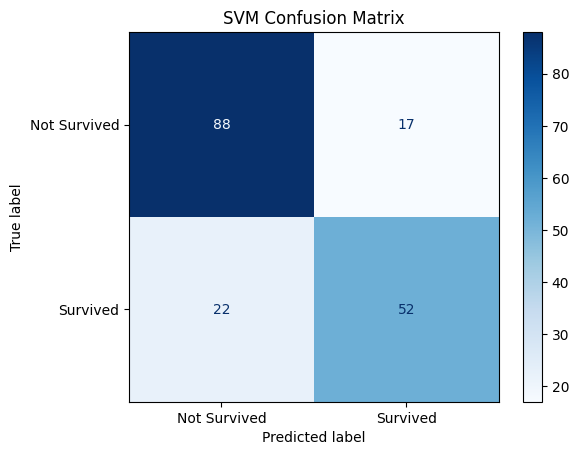

In [316]:
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Not Survived", "Survived"]
)

disp.plot(cmap="Blues")

plt.title("SVM Confusion Matrix")

plt.show()


In [317]:
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy :", accuracy_score(y_test, y_pred))
print("Precision:", precision)
print("Recall   :", recall)
print("F1 Score :", f1)

Accuracy : 0.7821229050279329
Precision: 0.7536231884057971
Recall   : 0.7027027027027027
F1 Score : 0.7272727272727273


In [318]:
from sklearn.model_selection import cross_val_score

cv_scores = cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="accuracy"
)

print("Cross Validation Scores:", cv_scores)
print(f"Mean Accuracy: {cv_scores.mean():.4f}")
print(f"Standard Deviation: {cv_scores.std():.4f}")

Cross Validation Scores: [0.7972028  0.8041958  0.75352113 0.76056338 0.82394366]
Mean Accuracy: 0.7879
Standard Deviation: 0.0268


In [319]:
C_values = [0.01, 0.1, 1, 10, 100]

train_acc = []
test_acc = []

for c in C_values:

    svm = SVC(
        kernel="linear",
        C=c,
        random_state=42
    )

    svm.fit(X_train, y_train)

    train_acc.append(svm.score(X_train, y_train))
    test_acc.append(svm.score(X_test, y_test))

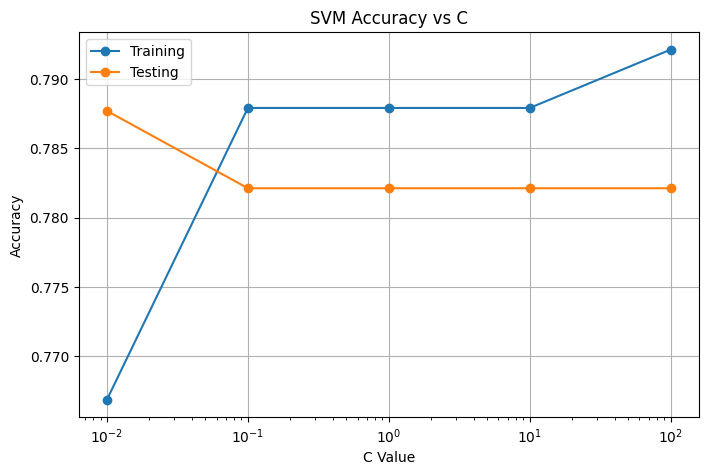

In [320]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.plot(C_values, train_acc, marker="o", label="Training")
plt.plot(C_values, test_acc, marker="o", label="Testing")

plt.xscale("log")

plt.xlabel("C Value")
plt.ylabel("Accuracy")

plt.title("SVM Accuracy vs C")

plt.legend()

plt.grid(True)

plt.show()

In [321]:
kernels = ["linear", "rbf", "poly", "sigmoid"]

for kernel in kernels:

    svm = SVC(
        kernel=kernel,
        random_state=42
    )

    svm.fit(X_train, y_train)

    score = svm.score(X_test, y_test)

    print(f"{kernel.capitalize()} Kernel Accuracy: {score:.4f}")

Linear Kernel Accuracy: 0.7821
Rbf Kernel Accuracy: 0.6592
Poly Kernel Accuracy: 0.6089
Sigmoid Kernel Accuracy: 0.6145


## 📌 Conclusion

In this notebook, the **Support Vector Machine (SVM)** algorithm was successfully implemented and evaluated for the Titanic classification problem. The model was assessed using **Accuracy, Precision, Recall, F1-Score, Confusion Matrix, and 5-Fold Cross Validation**, providing a comprehensive evaluation of its performance.

Beyond building a basic SVM classifier, different aspects of the algorithm were explored, including the effect of the **regularization parameter (C)** and the performance of different **kernel functions** such as Linear, Polynomial, RBF, and Sigmoid. This demonstrated how kernel selection influences the decision boundary and overall classification performance.

### Key Takeaways

- Implemented Support Vector Machine (SVM) for binary classification.
- Learned the concepts of hyperplanes, margins, support vectors, and the kernel trick.
- Evaluated model performance using multiple classification metrics.
- Applied 5-Fold Cross Validation to estimate model generalization.
- Explored the impact of different **C** values on model performance.
- Compared multiple kernel functions to identify the most suitable kernel for the dataset.

Overall, this notebook strengthened my understanding of Support Vector Machines by combining theoretical concepts with practical implementation. It demonstrated that selecting an appropriate kernel, tuning hyperparameters, and evaluating models using cross-validation are essential steps in building robust and reliable machine learning classifiers.